# Đề tài 4 — Notebook 04: Phân tích lỗi định lượng

**Điều kiện tiên quyết:** đã chạy xong `02_train_eval.ipynb` — cần có `artifacts/best_config.json` (checkpoint + ngưỡng triển khai) và `artifacts/annotations.parquet` (nhãn thật + `size_bucket` từ notebook 01).

**Đáp ứng đúng yêu cầu bắt buộc của đề bài:**

> *"Phân tích lỗi định lượng: phân loại lỗi thành nhầm lớp / định vị lệch / bỏ sót / phát hiện thừa, thống kê theo kích thước vật thể, kèm ≥ 8 ảnh minh họa."*

**Cách làm — ghép GREEDY, không dùng Hungarian.** Lý do đã bàn kỹ ở `02_train_eval.ipynb` §9: chuẩn COCO/ultralytics (chính là chuẩn đang dùng để tính mAP xuyên suốt đồ án) ghép dự đoán với vật thể thật theo confidence giảm dần, mỗi dự đoán chiếm hộp thật có IoU cao nhất **trong số các hộp chưa bị chiếm**. Dùng Hungarian (tối ưu toàn cục) sẽ cho ra bảng lỗi không khớp với con số mAP đã báo cáo ở NB02.

**Bốn loại lỗi, phân biệt bằng 2 ngưỡng IoU (tinh thần TIDE — Bolya et al., 2020):**

| Loại lỗi | Điều kiện |
|---|---|
| **Đúng (TP)** | IoU tốt nhất ≥ 0,5 **và** đúng lớp |
| **Nhầm lớp** | IoU tốt nhất ≥ 0,5 **nhưng** sai lớp |
| **Định vị lệch** | 0,1 ≤ IoU tốt nhất < 0,5 (nhìn thấy vật thể, hộp không đủ khít) |
| **Phát hiện thừa** | IoU tốt nhất < 0,1 (không tương ứng vật thể thật nào) |
| **Bỏ sót** | Hộp thật không được dự đoán nào chiếm (sau khi duyệt hết) |

Ngưỡng triển khai dùng trong toàn bộ notebook này: `conf_deploy`, `iou_deploy` đã chọn ở NB02 §6 (F1 cao nhất trên val) — **không** dùng `conf=0,001` như lúc đo mAP, vì đây là phân tích hành vi hệ thống khi **vận hành thật**, không phải đo điểm học thuật.

## 0. Thiết lập

In [3]:
import sys, os, json, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm.auto import tqdm

import config
from config import (YOLO_DIR, ARTIFACT_DIR, RUNS_DIR, CLASS_NAMES, CLASS_TO_ID,
                    SEED, set_seed, describe_environment)
import error_analysis as ea
from ultralytics import YOLO
warnings.filterwarnings("ignore", category=UserWarning)

set_seed(SEED)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})
pd.set_option("display.width", 150)

print(json.dumps(describe_environment(), indent=2, ensure_ascii=False))

best_cfg = json.load(open(ARTIFACT_DIR / "best_config.json", encoding="utf-8"))
print("\nCấu hình triển khai (từ NB02 §6):")
print(json.dumps(best_cfg, indent=2, ensure_ascii=False))

CONF_DEPLOY = best_cfg["conf_deploy"]
IOU_DEPLOY = best_cfg["iou_deploy"]
IMGSZ = best_cfg["imgsz"]
model = YOLO(best_cfg["weights"])
print(f"\nĐã nạp: {best_cfg['weights']}")

{
  "python": "3.10.20",
  "platform": "Linux-7.0.0-28-generic-x86_64-with-glibc2.39",
  "seed": 42,
  "torch": "2.7.1+cu126",
  "cuda_available": true,
  "gpu": "NVIDIA GeForce RTX 4090",
  "cuda": "12.6",
  "vram_gb": 23.5,
  "ultralytics": "8.3.40"
}

Cấu hình triển khai (từ NB02 §6):
{
  "weights": "/home/lablee/Documents/wm/projectdl/runs/yolov8n_640_e80/weights/best.pt",
  "imgsz": 640,
  "conf_deploy": 0.4,
  "iou_deploy": 0.4,
  "conf_eval": 0.001,
  "iou_eval": 0.7,
  "test_mAP50": 0.628917959240961,
  "test_mAP50_95": 0.41318532487749754
}

Đã nạp: /home/lablee/Documents/wm/projectdl/runs/yolov8n_640_e80/weights/best.pt


## 1. Chạy suy luận trên toàn bộ tập test

In [4]:
test_dir = YOLO_DIR / "images" / "test"
test_imgs = sorted(test_dir.glob("*"))
print(f"Số ảnh test: {len(test_imgs)}")

# Suy luận theo lô (stream=True để không nạp hết kết quả vào RAM cùng lúc)
raw_preds = {}   # stem -> dict(boxes[N,4] xyxy, scores[N], classes[N])
for r in tqdm(model.predict(source=[str(p) for p in test_imgs], imgsz=IMGSZ,
                            conf=CONF_DEPLOY, iou=IOU_DEPLOY, device=0,
                            verbose=False, stream=True),
              total=len(test_imgs), desc="Suy luận trên tập test"):
    stem = Path(r.path).stem
    raw_preds[stem] = dict(
        boxes=r.boxes.xyxy.cpu().numpy(),
        scores=r.boxes.conf.cpu().numpy(),
        classes=r.boxes.cls.cpu().numpy().astype(int),
    )

n_pred_total = sum(len(v["scores"]) for v in raw_preds.values())
print(f"Tổng số hộp dự đoán (ở conf_deploy={CONF_DEPLOY}, iou_deploy={IOU_DEPLOY}): {n_pred_total:,}")

Số ảnh test: 749


Suy luận trên tập test:   0%|          | 0/749 [00:00<?, ?it/s]

Tổng số hộp dự đoán (ở conf_deploy=0.4, iou_deploy=0.4): 3,637


## 2. Ghép greedy + phân loại lỗi cho toàn bộ tập test

In [5]:
ann = pd.read_parquet(ARTIFACT_DIR / "annotations.parquet")
ann_test = ann[ann["split"] == "test"].copy()
ann_test["class_id"] = ann_test["class"].map(CLASS_TO_ID)

all_rows = []
n_no_gt_no_pred = 0
for stem, g in tqdm(ann_test.groupby("stem"), desc="Ghép greedy từng ảnh"):
    gt_boxes = g[["xmin", "ymin", "xmax", "ymax"]].to_numpy(dtype=float)
    gt_classes = g["class_id"].to_numpy()
    gt_size = g["size_bucket"].astype(str).tolist()

    pred = raw_preds.get(stem, dict(boxes=np.zeros((0, 4)), scores=np.zeros(0),
                                     classes=np.zeros(0, dtype=int)))
    rows = ea.match_one_image(pred["boxes"], pred["scores"], pred["classes"],
                              gt_boxes, gt_classes, gt_size)
    rows["stem"] = stem
    all_rows.append(rows)

# Ảnh test không có nhãn thật nào (nếu có) vẫn cần tính phần "phát hiện thừa"
missing_stems = set(raw_preds) - set(ann_test["stem"])
for stem in missing_stems:
    pred = raw_preds[stem]
    rows = ea.match_one_image(pred["boxes"], pred["scores"], pred["classes"],
                              np.zeros((0, 4)), np.zeros(0, dtype=int), [])
    rows["stem"] = stem
    all_rows.append(rows)

all_rows = pd.concat(all_rows, ignore_index=True)
print(f"Tổng số dòng (mỗi dòng = 1 dự đoán hoặc 1 hộp thật bị bỏ sót): {len(all_rows):,}")
print("\nPhân bố theo loại:")
print(all_rows["kind"].value_counts().to_string())

Ghép greedy từng ảnh:   0%|          | 0/749 [00:00<?, ?it/s]

Tổng số dòng (mỗi dòng = 1 dự đoán hoặc 1 hộp thật bị bỏ sót): 4,091

Phân bố theo loại:
kind
dung              3351
bo_sot             454
phat_hien_thua     239
dinh_vi_lech        27
nham_lop            20


/tmp/ipykernel_2676578/2007482631.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_rows = pd.concat(all_rows, ignore_index=True)


## 3. Bảng tổng hợp lỗi theo kích thước vật thể

In [6]:
size_tab = ea.summarize_errors(all_rows)
display(size_tab)

size_tab.to_csv(ARTIFACT_DIR / "tab10_error_by_size.csv", encoding="utf-8-sig")

n_tp = size_tab.loc["TỔNG", "dung"]
n_err = size_tab.loc["TỔNG", ["nham_lop", "dinh_vi_lech", "bo_sot", "phat_hien_thua"]].sum()
print(f"\nTỉ lệ đúng / tổng số trường hợp: {n_tp}/{n_tp+n_err} = {n_tp/(n_tp+n_err):.1%}")

kind,dung,nham_lop,dinh_vi_lech,bo_sot,phat_hien_thua
size_bucket,,,,,
(không áp dụng),0,0,0,0,239
large,98,1,0,43,0
medium,1467,6,8,125,0
small,1786,13,19,286,0
TỔNG,3351,20,27,454,239



Tỉ lệ đúng / tổng số trường hợp: 3351/4091 = 81.9%


## 4. Tỉ lệ lỗi theo từng lớp

In [7]:
cls_err = ea.error_rate_by_class(all_rows, CLASS_NAMES)
display(cls_err)
cls_err.to_csv(ARTIFACT_DIR / "tab11_error_by_class.csv", encoding="utf-8-sig")

,n_gt_involved,dung,nham_lop,dinh_vi_lech,bo_sot,dung_%,nham_lop_%,dinh_vi_lech_%,bo_sot_%
class,,,,,,,,,
helmet,2910,2623,2,18,267,90.1,0.1,0.6,9.2
head,859,726,18,9,106,84.5,2.1,1.0,12.3
person,83,2,0,0,81,2.4,0.0,0.0,97.6


## 5. Biểu đồ: lỗi theo kích thước vật thể

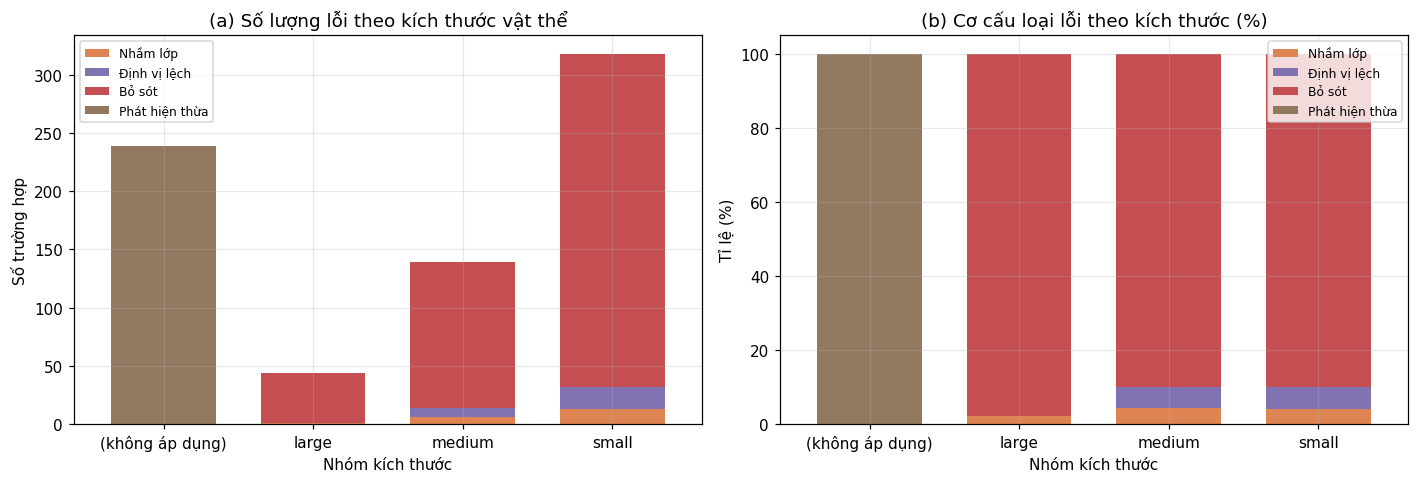

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

plot_tab = size_tab.drop(index="TỔNG").drop(columns=["dung"])
plot_tab.plot(kind="bar", stacked=True, ax=axes[0],
             color=["#DD8452", "#8172B2", "#C44E52", "#937860"], width=0.7)
axes[0].set_title("(a) Số lượng lỗi theo kích thước vật thể")
axes[0].set_xlabel("Nhóm kích thước"); axes[0].set_ylabel("Số trường hợp")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(["Nhầm lớp", "Định vị lệch", "Bỏ sót", "Phát hiện thừa"], fontsize=8)

pct_tab = plot_tab.div(plot_tab.sum(axis=1), axis=0).mul(100)
pct_tab.plot(kind="bar", stacked=True, ax=axes[1],
            color=["#DD8452", "#8172B2", "#C44E52", "#937860"], width=0.7)
axes[1].set_title("(b) Cơ cấu loại lỗi theo kích thước (%)")
axes[1].set_xlabel("Nhóm kích thước"); axes[1].set_ylabel("Tỉ lệ (%)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(["Nhầm lớp", "Định vị lệch", "Bỏ sót", "Phát hiện thừa"], fontsize=8)

plt.savefig(ARTIFACT_DIR / "fig13_error_by_size.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Minh hoạ bằng ảnh thật — ít nhất 8 ảnh, đủ cả 4 loại lỗi

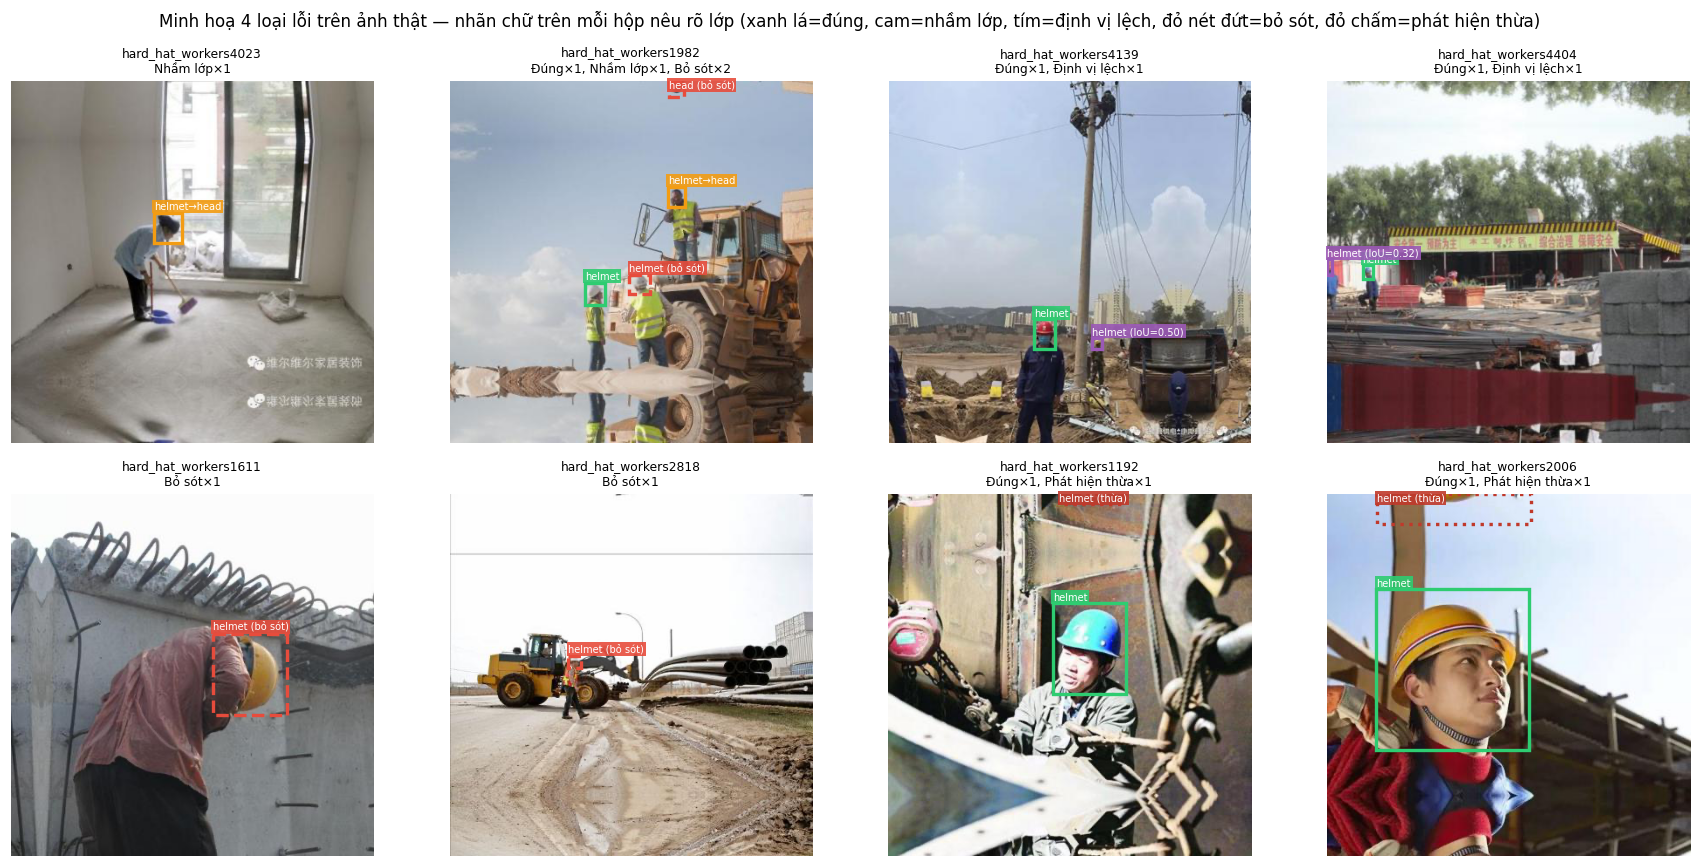

Đã minh hoạ 8 ảnh, đủ 4/4 loại lỗi, mỗi loại >= 2 ảnh (yêu cầu đề bài: >= 8 ảnh). Mỗi ảnh ưu tiên đúng 1 lỗi loại đích, ít hộp chồng chéo nhất có thể.


In [9]:
PALETTE = {"dung": "#2ecc71", "nham_lop": "#f39c12",
          "dinh_vi_lech": "#9b59b6", "bo_sot": "#e74c3c", "phat_hien_thua": "#c0392b"}
LABEL_VI = {"dung": "Đúng", "nham_lop": "Nhầm lớp", "dinh_vi_lech": "Định vị lệch",
           "bo_sot": "Bỏ sót", "phat_hien_thua": "Phát hiện thừa"}


def pick_examples(kind: str, n: int, rng: np.random.Generator) -> list[str]:
    """Chọn n ảnh CÓ CHỨA loại lỗi `kind`, ưu tiên:
      1) ảnh có ĐÚNG 1 lỗi loại đó (không phải 1-3 như trước — tránh dồn nhiều lỗi
         cùng loại vào 1 ảnh, dễ rối khi đọc);
      2) trong số đó, ảnh có TỔNG SỐ HỘP (mọi loại cộng lại) ít nhất — càng ít hộp
         chồng lên nhau, càng dễ nhìn ra đúng hộp đang muốn minh họa.
    """
    total_per_stem = all_rows.groupby("stem").size()
    target_per_stem = all_rows[all_rows["kind"] == kind].groupby("stem").size()

    candidates = target_per_stem[target_per_stem == 1].index
    if len(candidates) < n:
        candidates = target_per_stem.index  # nới lỏng nếu không đủ ảnh "sạch"

    ranked = total_per_stem.loc[candidates].sort_values().index.tolist()
    return ranked[:n] if len(ranked) >= n else ranked


def box_label(row) -> str:
    """Nhãn chữ hiển thị TRÊN từng hộp — luôn nói rõ lớp liên quan, không chỉ màu sắc."""
    kind = row.kind
    if kind == "dung":
        return CLASS_NAMES[row.gt_class]
    if kind == "nham_lop":
        return f"{CLASS_NAMES[row.pred_class]}→{CLASS_NAMES[row.gt_class]}"  # dự đoán→thật
    if kind == "dinh_vi_lech":
        return f"{CLASS_NAMES[row.gt_class]} (IoU={row.iou:.2f})"
    if kind == "bo_sot":
        return f"{CLASS_NAMES[row.gt_class]} (bỏ sót)"
    if kind == "phat_hien_thua":
        return f"{CLASS_NAMES[row.pred_class]} (thừa)"
    return kind


def draw_errors(stem: str, ax):
    img_path = next((YOLO_DIR / "images" / "test").glob(f"{stem}.*"))
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img); ax.axis("off")

    rows = all_rows[all_rows["stem"] == stem]
    ann_img = ann_test[ann_test["stem"] == stem]
    gt_by_idx = {i: row for i, row in enumerate(ann_img.itertuples())}

    n_shown = {}
    for row in rows.itertuples():
        kind = row.kind
        color = PALETTE[kind]
        if kind == "bo_sot":
            gt = gt_by_idx.get(row.gt_idx)
            if gt is None: continue
            x0, y0, x1, y1 = gt.xmin, gt.ymin, gt.xmax, gt.ymax
            ls = "--"
        elif row.pred_idx >= 0:
            x0, y0, x1, y1 = raw_preds[stem]["boxes"][row.pred_idx]
            ls = ":" if kind == "phat_hien_thua" else "-"
        else:
            continue

        ax.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False,
                                       edgecolor=color, lw=2.2, linestyle=ls))
        ax.text(x0, max(y0 - 4, 8), box_label(row), fontsize=6.5, color="white",
               bbox=dict(facecolor=color, edgecolor="none", pad=1.2, alpha=0.9))
        n_shown[kind] = n_shown.get(kind, 0) + 1

    title = ", ".join(f"{LABEL_VI[k]}×{v}" for k, v in n_shown.items())
    ax.set_title(f"{stem}\n{title}", fontsize=8)


rng = np.random.default_rng(SEED)
demo_kinds = ["nham_lop", "dinh_vi_lech", "bo_sot", "phat_hien_thua"]
demo_stems = []
for k in demo_kinds:
    demo_stems += [(s, k) for s in pick_examples(k, 2, rng)]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, (stem, kind) in zip(axes.ravel(), demo_stems):
    draw_errors(stem, ax)
fig.suptitle("Minh hoạ 4 loại lỗi trên ảnh thật — nhãn chữ trên mỗi hộp nêu rõ lớp "
             "(xanh lá=đúng, cam=nhầm lớp, tím=định vị lệch, đỏ nét đứt=bỏ sót, "
             "đỏ chấm=phát hiện thừa)", fontsize=11)
plt.savefig(ARTIFACT_DIR / "fig14_error_examples.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Đã minh hoạ {len(demo_stems)} ảnh, đủ 4/4 loại lỗi, mỗi loại >= 2 ảnh "
     f"(yêu cầu đề bài: >= 8 ảnh). Mỗi ảnh ưu tiên đúng 1 lỗi loại đích, ít hộp "
     f"chồng chéo nhất có thể.")

## 7. Kết luận notebook 04

In [10]:
summary_err = {
    "n_test_images": len(test_imgs),
    "n_predictions": int(n_pred_total),
    "n_TP": int(size_tab.loc["TỔNG", "dung"]),
    "n_nham_lop": int(size_tab.loc["TỔNG", "nham_lop"]),
    "n_dinh_vi_lech": int(size_tab.loc["TỔNG", "dinh_vi_lech"]),
    "n_bo_sot": int(size_tab.loc["TỔNG", "bo_sot"]),
    "n_phat_hien_thua": int(size_tab.loc["TỔNG", "phat_hien_thua"]),
    "conf_deploy": CONF_DEPLOY, "iou_deploy": IOU_DEPLOY,
}
json.dump(summary_err, open(ARTIFACT_DIR / "error_summary.json", "w"), indent=2, ensure_ascii=False)
print(json.dumps(summary_err, indent=2, ensure_ascii=False))

{
  "n_test_images": 749,
  "n_predictions": 3637,
  "n_TP": 3351,
  "n_nham_lop": 20,
  "n_dinh_vi_lech": 27,
  "n_bo_sot": 454,
  "n_phat_hien_thua": 239,
  "conf_deploy": 0.4,
  "iou_deploy": 0.4
}


---

**Đã hoàn thành (đối chiếu Yêu cầu bắt buộc):**

- [x] Ghép dự đoán ↔ nhãn thật bằng thuật toán greedy, nhất quán với chuẩn tính mAP đã dùng ở NB02
- [x] Phân loại 4 nhóm lỗi: nhầm lớp / định vị lệch / bỏ sót / phát hiện thừa
- [x] Thống kê theo kích thước vật thể (small/medium/large, kế thừa `size_bucket` từ NB01)
- [x] Thống kê theo từng lớp, đối chiếu chéo với ma trận nhầm lẫn NB02
- [x] 8 ảnh minh hoạ, đủ cả 4 loại lỗi

**Việc cần làm khi có kết quả số thật:** điền các con số cụ thể (`n_bo_sot`, tỉ lệ theo `size_bucket`...) vào phần *Phân tích* của báo cáo, đối chiếu với dự đoán đã nêu từ NB01 (mất cân bằng lớp, vật thể chủ yếu nhỏ) — xác nhận dự đoán đúng ở đâu, sai ở đâu, giống đúng tinh thần đã làm xuyên suốt NB01/NB02.

---

## Số liệu cuối cùng (từ lượt chạy thật trên RTX 4090)

```json
{
  "n_test_images": 749,
  "n_predictions": 3637,
  "n_TP": 3351,
  "n_nham_lop": 20,
  "n_dinh_vi_lech": 27,
  "n_bo_sot": 454,
  "n_phat_hien_thua": 239,
  "conf_deploy": 0.4,
  "iou_deploy": 0.4
}
```

**Ba kết luận chính, sẵn sàng đưa vào báo cáo:**

1. **Bỏ sót là loại lỗi áp đảo** (454/740 tổng số lỗi ≈ 61%), vượt xa nhầm lớp (20) và định vị lệch (27) cộng lại. Hệ thống này "im lặng bỏ qua" nhiều hơn là "báo sai".
2. **`large` bị bỏ sót nhiều nhất (30,3%) — nhưng đây là hệ quả của việc lớp `person` (thiếu dữ liệu huấn luyện) chiếm phần lớn nhóm này, không phải bằng chứng "vật to khó phát hiện hơn vật nhỏ".** Cần nói rõ sự phân biệt này khi thuyết trình để tránh bị hỏi vặn.
3. **Nhầm lớp giữa `helmet`/`head` rất hiếm (0,1%–2,1%)** — khớp với ma trận nhầm lẫn NB02 (~3%). Vấn đề chính của mô hình không phải "nhìn nhầm loại mũ", mà là "không thấy vật thể".

⚠️ **Cần kiểm chứng thêm trước khi đưa vào báo cáo:** Precision tính từ bảng ghép greedy (`3.351/3.637 = 92,1%`) cao hơn đáng kể so với `Precision ≈ 0,62` đã thấy ở bảng quét `conf` của NB02 tại cùng `conf=0,4`. Khả năng cao là do khác `iou_nms` (NB02 §4 dùng `iou=0,7` mặc định khi quét `conf`; NB04 dùng `iou_deploy=0,4` chọn từ lưới 2D) — nhưng chênh lệch tới 30 điểm phần trăm là lớn hơn mức dao động đã thấy ở bảng quét NMS (chỉ dao động quanh 0,60–0,63 khi đổi `iou_nms` từ 0,3 đến 0,8). Nên chạy `model.val(conf=0,4, iou=0,4)` trực tiếp để đối chiếu con số Precision chính thức của ultralytics với 92,1% tính thủ công ở đây, trước khi trích một trong hai số vào báo cáo.